In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import json
import pandas as pd
import os
import zipfile
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np

In [ ]:
# Set dataset path
dataset_path = "/content/drive/My Drive/licenta/balanced"

# List available files
files = os.listdir(dataset_path)
print("Files in dataset:", files)

Files in dataset: ['test_balanced_questions.json', 'shortAnswer_translated.json', 'testdev_balanced_questions.json', 'val_balanced_questions.json', 'train_subset_balanced.json', 'val_subset_balanced.json', 'val_top500_filtered.json', 'test_top500_filtered.json', 'train_top500_subset.json', 'val_top500_subset.json', 'test_top500_subset.json', 'train_top500_100k.json', 'val_top500_balanced.json', 'test_top500_full.json', 'answer_vocab_top500.json', 'train_top100_shared_balanced.json', 'val_top100_shared_balanced.json', 'train_top100_cluster.json', 'val_top100_cluster.json', 'test_top100_shared_balanced.json', 'train_final.json']


In [ ]:
import os
import zipfile

zip_path = "/content/drive/My Drive/licenta/images.zip"  # Adjust if different name
extract_path = "/content/data"  # Folder where you'll unzip

# Create the directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


In [ ]:
import os

image_dir = "/content/data/images"

# 1. List all files in /content/data
all_files = os.listdir(image_dir)

# 2. Filter by image extensions
image_files = [f for f in all_files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

# 3. Print stats
print(f"Total files in '{image_dir}': {len(all_files)}")
print(f"Total images (jpg/png/jpeg): {len(image_files)}")
print(f"First 5 images: {image_files[:5]}")

Total files in '/content/data/images': 148854
Total images (jpg/png/jpeg): 148854
First 5 images: ['2376592.jpg', '2362999.jpg', '2350530.jpg', '2334730.jpg', '1592704.jpg']


In [ ]:
# import os
# from PIL import Image            # pip install pillow  (if not already)

# image_dir   = "/content/data/images"
# target_dir  = "/content/data/resized_336"

# # Make the output folder once; no error if it already exists
# os.makedirs(target_dir, exist_ok=True)

# # 1-2. Collect image filenames you already printed
# all_files   = os.listdir(image_dir)
# image_files = [f for f in all_files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

# # 3-4. Resize and save
# for fname in image_files:
#     src_path = os.path.join(image_dir, fname)
#     dst_path = os.path.join(target_dir, fname)

#     try:
#         with Image.open(src_path) as im:
#             im = im.convert("RGB")                    # normalise mode
#             im_resized = im.resize((336, 336), Image.LANCZOS)
#             im_resized.save(dst_path, quality=95)     # keep good quality
#     except Exception as e:
#         print(f"⚠️  Skipping {fname}: {e}")

# print(f"✅ Saved {len(os.listdir(target_dir))} images in '{target_dir}'.")


In [ ]:
import os
from pathlib import Path

image_dir = "/content/data/images"

# 1. List all files
all_files = os.listdir(image_dir)

# 2. Filter by image extensions
image_files = [f for f in all_files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

# 3. Show basic stats
print(f"Total files in '{image_dir}': {len(all_files)}")
print(f"Total images (jpg/png/jpeg): {len(image_files)}")
print(f"First 5 images: {image_files[:5]}\n")

# 4. Print sizes of the first 5 images
print("File name".ljust(30), "Size (KB)")
for fname in image_files[:5]:
    path = Path(image_dir) / fname
    size_bytes = path.stat().st_size        # or os.path.getsize(path)
    size_kb = size_bytes / 1024
    print(fname.ljust(30), f"{size_kb:8.2f}")


Total files in '/content/data/images': 148854
Total images (jpg/png/jpeg): 148854
First 5 images: ['2376592.jpg', '2362999.jpg', '2350530.jpg', '2334730.jpg', '1592704.jpg']

File name                      Size (KB)
2376592.jpg                      168.12
2362999.jpg                       92.33
2350530.jpg                      234.21
2334730.jpg                      235.87
1592704.jpg                      563.07


In [ ]:
dataset_path = "/content/drive/My Drive/vqa_clean/dataset_final"

def load_dataset(json_path):
    json_path = os.path.join(dataset_path, json_path)
    with open(json_path, "r", encoding="utf-8") as f:
        data_json = json.load(f)
    df = pd.DataFrame.from_dict(data_json, orient="index")
    # df["question"] = df["question"]
    # df["answer"] = df["answer_clean"]
    # df["imageId"] = df["imageId"]
    return df

# train_df = load_dataset("train_with_caption.json")
# val_df = load_dataset("val_with_caption.json")
# test_df = load_dataset("test_with_caption.json")

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9\.]{3,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.32.post2" if v == "2.8.0" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.57.0
!pip install --no-deps trl==0.22.2

In [ ]:
import os
import torch
import pandas as pd
from PIL import Image
from datasets import Dataset
# from unsloth import FastVisionModel
# from trl import SFTTrainer

In [ ]:
train_df = load_dataset("train_with_caption_updated.json")
# val_df = load_dataset("val_with_caption.json")
# test_df = load_dataset("test_with_caption.json")

In [ ]:
# train_df = stem_all(train_df)
# val_df   = stem_all(val_df)
# test_df  = stem_all(test_df)

In [ ]:
train_dataset = Dataset.from_pandas(train_df)
# val_dataset = Dataset.from_pandas(val_df)
# test_dataset = Dataset.from_pandas(test_df)

In [ ]:
# --- 2. Get the Set of Required Image IDs ---
# Using a set provides the fastest possible lookup.
required_image_ids = set(train_df['imageId'])
# required_image_ids.update(val_df['imageId'])
print(f"Identified {len(required_image_ids)} unique images needed for training.")


Identified 46565 unique images needed for training.


In [ ]:
image_root = "/content/data/images"
output_dir = "/content/preprocessed/train"  # unde vor fi salvate json-urile

In [ ]:
from tqdm import tqdm


In [ ]:
image_cache = {}
print("\nCaching only the required images...")

# Get a list of all potential image files in the directory
all_image_filenames = [f for f in os.listdir(image_root) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

for filename in tqdm(all_image_filenames, desc="Caching required images"):
    # Extract the image ID from the filename (e.g., "n12345.jpg" -> "n12345")
    image_id = os.path.splitext(filename)[0]

    # This is the key optimization: Check if the image is actually needed
    if image_id in required_image_ids:
        path = os.path.join(image_root, filename)
        try:
            image = Image.open(path).convert("RGB")
            image_cache[image_id] = image
        except Exception as e:
            print(f"⚠️ Failed to load required image {filename}: {e}")

print(f"\n✅ Successfully cached {len(image_cache)} images required for the training run.")



Caching only the required images...


Caching required images: 100%|██████████| 148854/148854 [02:31<00:00, 984.30it/s] 


✅ Successfully cached 46565 images required for the training run.


In [ ]:
print(train_dataset[0])

{'semantic': [{'argument': 'scene', 'dependencies': [], 'operation': 'select'}, {'argument': 'place', 'dependencies': [0], 'operation': 'query'}], 'entailed': ['11106190', '11106188', '11106189', '11106186'], 'equivalent': ['11106187'], 'question': 'Ce loc este?', 'imageId': '2339497', 'isBalanced': True, 'groups': {'global': 'place', 'local': '02q-place'}, 'answer': 'camp', 'semanticStr': 'select: scene->query: place [0]', 'annotations': {'answer': {'0': None, '0:2': None}, 'fullAnswer': {'1': None, '10': None, '10:12': None, '11': None, '11:13': None, '1:3': None, '1:4': None, '2': None, '2:4': None, '3': None, '3:5': None, '4': None, '4:6': None, '4:7': None, '5': None, '5:7': None, '5:8': None, '6': None, '6:8': None, '7': None, '7:9': None, '8': None, '8:10': None, '9': None, '9:11': None}, 'question': {'0': None, '1': None, '10': None, '10:12': None, '10:13': None, '11': None, '11:13': None, '11:14': None, '12': None, '12:14': None, '12:15': None, '13': None, '13:15': None, '13:1

In [ ]:
!pip install albumentations

import albumentations as A
import numpy as np
from PIL import Image

In [ ]:
import random

# (Your existing instruction prompts)
INSTRUCTION_PROMPTS = [
    "Ești un asistent vizual care răspunde la întrebări despre imagine.",
    "Privește cu atenție imaginea și răspunde la întrebare.",
    "Analizează această imagine și oferă un răspuns la următoarea întrebare.",
    "Răspunde la întrebarea următoare pe baza imaginii furnizate.",
]

import albumentations as A
import numpy as np
from PIL import Image
import gc # Garbage Collector for RAM management

# Define the Light Augmentation Pipeline (Same as before)
# Updated for Albumentations 1.4+
vqa_augmentation_pipeline = A.Compose([
    # 1. Lighting: Simulate day/night or flash variance
    A.RandomBrightnessContrast(
        brightness_limit=0.2,  # +/- 20%
        contrast_limit=0.2,    # +/- 20%
        p=0.5
    ),

    # 2. Sensor Noise: (Replaced GaussNoise with ISONoise for new API)
    # Simulates ISO grain (common in low light photos)
    A.ISONoise(
        color_shift=(0.01, 0.05),
        intensity=(0.1, 0.5),
        p=0.3
    ),

    # 3. Blur: Motion or focus issues
    A.MotionBlur(
        blur_limit=3,
        p=0.2
    ),

    # 4. Compression: (Updated API: uses quality_range tuple now)
    A.ImageCompression(
        quality_range=(75, 100),
        p=0.3
    ),
], p=1.0)

def apply_visual_augmentation_optimized(pil_image):
    """
    RAM-Optimized: Aggressively deletes intermediate copies.
    """
    # 1. Create NumPy copy (RAM Spike #1)
    image_np = np.array(pil_image)

    # 2. Augment (RAM Spike #2 - creates processed copy)
    augmented_dict = vqa_augmentation_pipeline(image=image_np)
    augmented_np = augmented_dict["image"]

    # 3. DELETE Step 1 immediately
    del image_np
    del augmented_dict

    # 4. Convert back to PIL
    final_pil = Image.fromarray(augmented_np)

    # 5. DELETE Step 2 immediately
    del augmented_np

    return final_pil

# 1. SETUP PATHS
# Make sure this points to your actual image folder
IMAGE_FOLDER = "/content/data/images"

# 2. DEFINE DISK-BASED PREPROCESS
def preprocess_from_disk(example):
    """
    Loads image from DISK.
    Safe for recurrent images (multiple questions per image).
    """
    # Build the path
    img_id = example.get('imageId')

    # Try different extensions if needed, or assume .jpg
    # If your JSON has the full filename (e.g., "COCO_000.jpg"), use that.
    # If it just has ID (e.g. "2367842"), construct it:
    img_filename = f"{img_id}.jpg"
    full_path = os.path.join(IMAGE_FOLDER, img_filename)

    try:
        # Load from disk
        image = Image.open(full_path).convert('RGB')

        # Augment
        final_image = apply_visual_augmentation_optimized(image)

        # Cleanup raw load
        del image

    except Exception as e:
        # If file is missing on disk, we have to skip or use blank
        # print(f"File missing: {full_path}")
        raise ValueError(f"Could not load {img_id} from disk")

    # Text Logic (Same as before)
    available_questions = [example['question']]
    if example.get('question_ro_aug_fr'): available_questions.append(example['question_ro_aug_fr'])
    if example.get('question_ro_aug_it'): available_questions.append(example['question_ro_aug_it'])

    selected_question = random.choice(available_questions)
    instruction = random.choice(INSTRUCTION_PROMPTS)

    user_content = []
    user_content.append({"type": "image", "image": final_image})
    user_content.append({
        "type": "text",
        "text": f"{instruction}\n\nÎntrebare: {selected_question} Răspuns:"
    })

    return {"messages": [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": [{"type": "text", "text": example["answers_corrected"]}]}
    ]}

In [ ]:
# import random

# INSTRUCTION_PROMPTS = [
#     "Ești un asistent vizual care răspunde la întrebări despre imagine.",
#     "Privește cu atenție imaginea și răspunde la întrebare.",
#     "Analizează această imagine și oferă un răspuns la următoarea întrebare.",
#     "Răspunde la întrebarea următoare pe baza imaginii furnizate.",
# ]


# def preprocess(example):
#     image = image_cache.get(example["imageId"])
#     if image is None:
#         raise ValueError(f"Image {example['imageId']} not found in cache.")

#     instruction = random.choice(INSTRUCTION_PROMPTS)
#     conversation = [
#         {"role": "user", "content": [
#             {"type": "text", "text": instruction},
#             {"type": "image", "image": image},
#             {"type": "text", "text": f"Întrebare: {example['question']} Răspuns:"}
#         ]},
#         {"role": "assistant", "content": [
#             {"type": "text", "text": example["answers_corrected"]}
#         ]},
#     ]
#     return {"messages": conversation}


In [ ]:
# import random

# INSTRUCTION_PROMPTS = [
#     "Ești un asistent vizual care răspunde la întrebări despre imagine.",
#     "Privește cu atenție imaginea și răspunde la întrebare.",
#     "Analizează această imagine și oferă un răspuns la următoarea întrebare.",
#     "Răspunde la întrebarea următoare pe baza imaginii furnizate.",
# ]

# def preprocess(example):
#     # 1. Încărcare imagine (codul tău existent)
#     image = image_cache.get(example["imageId"])
#     if image is None:
#         # Poți pune un fallback sau lăsa eroarea
#         raise ValueError(f"Image {example['imageId']} not found in cache.")

#     # ================= LOGICA DE AUGMENTARE AICI =================

#     # Creează o listă cu întrebarea originală
#     available_questions = [example['question']]

#     # Verifică și adaugă varianta prin Franceză (dacă există în JSON)
#     if example.get('question_ro_aug_fr'):
#         available_questions.append(example['question_ro_aug_fr'])

#     # Verifică și adaugă varianta prin Italiană (dacă există în JSON)
#     if example.get('question_ro_aug_it'):
#         available_questions.append(example['question_ro_aug_it'])

#     # Alege UNA singură, aleatoriu, pentru acest pas de antrenament
#     selected_question = random.choice(available_questions)

#     # =============================================================

#     instruction = random.choice(INSTRUCTION_PROMPTS)

#     conversation = [
#         {"role": "user", "content": [
#             {"type": "text", "text": instruction},
#             {"type": "image", "image": image},
#             # Aici folosim 'selected_question' în loc de 'example["question"]'
#             {"type": "text", "text": f"Întrebare: {selected_question} Răspuns:"}
#         ]},
#         {"role": "assistant", "content": [
#             {"type": "text", "text": example["answers_corrected"]}
#         ]},
#     ]

#     return {"messages": conversation}

In [ ]:
# import random

# # Lista de instrucțiuni rămâne neschimbată
# INSTRUCTION_PROMPTS = [
#     "Ești un asistent vizual care răspunde la întrebări despre imagine.",
#     "Privește cu atenție imaginea și răspunde la întrebare.",
#     "Analizează această imagine și oferă un răspuns la următoarea întrebare.",
#     "Răspunde la întrebarea următoare pe baza imaginii furnizate.",
# ]

# def preprocess(example):
#     """
#     Prepares an example including:
#     1. Random Instruction
#     2. Optional LLAVA caption context
#     3. Random Question Augmentation (Original vs Backtranslated)
#     """
#     # 1. Încărcare imagine
#     image = image_cache.get(example["imageId"])
#     if image is None:
#         raise ValueError(f"Image {example['imageId']} not found in cache.")

#     # 2. Extragere Caption LLAVA (dacă există)
#     caption_llava = example.get("caption_llava", "").strip()

#     # ================= LOGICA DE AUGMENTARE ÎNTREBARE =================
#     # Colectăm toate variantele disponibile pentru acest exemplu
#     available_questions = [example['question']] # Întotdeauna avem originalul

#     # Verificăm și adăugăm varianta Franceză (dacă există și nu e goală)
#     if example.get('question_ro_aug_fr') and isinstance(example['question_ro_aug_fr'], str):
#         if len(example['question_ro_aug_fr'].strip()) > 1:
#             available_questions.append(example['question_ro_aug_fr'])

#     # Verificăm și adăugăm varianta Italiană
#     if example.get('question_ro_aug_it') and isinstance(example['question_ro_aug_it'], str):
#         if len(example['question_ro_aug_it'].strip()) > 1:
#             available_questions.append(example['question_ro_aug_it'])

#     # ALEGEREA ALEATORIE: Modelul va vedea una dintre aceste variante
#     selected_question = random.choice(available_questions)
#     # ==================================================================

#     # 3. Alegerea Instrucțiunii
#     instruction = random.choice(INSTRUCTION_PROMPTS)

#     # 4. Construirea Mesajului
#     user_content = []

#     # Adăugăm contextul LLAVA (Text) - ajută modelul să "vadă" mai bine
#     if caption_llava:
#         user_content.append({"type": "text", "text": f"Descriere context: {caption_llava}\n"})

#     # Adăugăm Imaginea (Image)
#     user_content.append({"type": "image", "image": image})

#     # Adăugăm Instrucțiunea + Întrebarea Augmentată (Text)
#     # Folosim 'selected_question' aici în loc de 'example["question"]'
#     user_content.append({
#         "type": "text",
#         "text": f"{instruction}\n\nÎntrebare: {selected_question} Răspuns:"
#     })

#     # 5. Asamblarea conversației finale
#     conversation = [
#         {"role": "user", "content": user_content},
#         {"role": "assistant", "content": [
#             {"type": "text", "text": example["answers_corrected"]}
#         ]},
#     ]

#     return {"messages": conversation}

In [ ]:
# import random

# # Translated instruction prompts
# INSTRUCTION_PROMPTS = [
#     "You are a visual assistant answering questions about the image.",
#     "Look closely at the image and answer the question.",
#     "Analyze this image and provide an answer to the following question.",
#     "Answer the following question based on the provided image.",
# ]

# def preprocess(example):
#     image = image_cache.get(example["imageId"])
#     if image is None:
#         raise ValueError(f"Image {example['imageId']} not found in cache.")

#     instruction = random.choice(INSTRUCTION_PROMPTS)

#     conversation = [
#         {"role": "user", "content": [
#             {"type": "text", "text": instruction},
#             {"type": "image", "image": image},
#             # Translated "Întrebare" and "Răspuns" to "Question" and "Answer"
#             {"type": "text", "text": f"Question: {example['question_eng']} Answer:"}
#         ]},
#         {"role": "assistant", "content": [
#             {"type": "text", "text": example["answer_eng"]}
#         ]},
#     ]
#     return {"messages": conversation}

In [ ]:
# import random

# # The list of instructions is re-added here.
# INSTRUCTION_PROMPTS = [
#     "Ești un asistent vizual care răspunde la întrebări despre imagine.",
#     "Privește cu atenție imaginea și răspunde la întrebare.",
#     "Analizează această imagine și oferă un răspuns la următoarea întrebare.",
#     "Răspunde la întrebarea următoare pe baza imaginii furnizate.",
# ]


# def preprocess(example):
#     """
#     Prepares an example for a vision model, including a random instruction
#     and an optional LLAVA caption.

#     Args:
#         example (dict): A dictionary containing the image ID, question, answer,
#                         and an optional "caption_llava" field.

#     Returns:
#         dict: A dictionary with a "messages" key, containing the
#               conversation history for the model.

#     Raises:
#         ValueError: If the imageId from the example is not found in the image_cache.
#     """
#     image = image_cache.get(example["imageId"])
#     if image is None:
#         raise ValueError(f"Image {example['imageId']} not found in cache.")

#     # Get the LLAVA caption, if it exists.
#     caption_llava = example.get("caption_llava", "").strip()

#     # --- The instruction is now selected here ---
#     instruction = random.choice(INSTRUCTION_PROMPTS)

#     # Start building the conversation for the user prompt.
#     user_content = []

#     # If a LLAVA caption is available, add it as context.
#     if caption_llava:
#         user_content.append({"type": "text", "text": f"Descriere LLAVA: {caption_llava}"})

#     # Add the image.
#     user_content.append({"type": "image", "image": image})

#     # --- The selected instruction is now added to the final text prompt ---
#     user_content.append({
#         "type": "text",
#         "text": f"{instruction}\n\nÎntrebare: {example['question']} Răspuns:"
#     })

#     # Assemble the final conversation structure.
#     conversation = [
#         {"role": "user", "content": user_content},
#         {"role": "assistant", "content": [
#             {"type": "text", "text": example["answer_clean"]}
#         ]},
#     ]

#     return {"messages": conversation}

In [ ]:
# def preprocess(example):
#     image = image_cache.get(example["imageId"])
#     if image is None:
#         raise ValueError(f"Image {example['imageId']} not found in cache.")

#     conversation = [
#         {"role": "user", "content": [
#             {"type": "text", "text": example["question"]},
#             {"type": "image", "image": image}
#         ]},
#         {"role": "assistant", "content": [
#             {"type": "text", "text": example["answer_clean"]}
#         ]},
#     ]
#     return {"messages": conversation}


In [ ]:
from tqdm import tqdm

train_dataset = [preprocess(sample) for sample in tqdm(train_dataset, desc="Preprocessing train", leave=True, ncols=100)]
# val_dataset = [preprocess(sample) for sample in tqdm(val_dataset, desc="Preprocessing val", leave=True, ncols=100)]

Preprocessing train: 100%|█████████████████████████████████| 100236/100236 [12:54<00:00, 129.48it/s]


In [ ]:
import os
from PIL import Image
from tqdm import tqdm
import gc


# 3. RUN THE LOOP (WITHOUT CACHE DELETION LOGIC)
final_train_dataset = []

print("🚀 Starting processing from DISK...")

for i, sample in enumerate(tqdm(train_dataset, desc="Processing from Disk")):
    try:
        # Use the DISK function
        processed_sample = preprocess_from_disk(sample)
        final_train_dataset.append(processed_sample)
    except Exception as e:
        # Only prints if file is actually missing from Google Drive
        # print(f"Missing file: {sample['imageId']}")
        continue

    # Garbage collect occasionally
    if i % 2000 == 0:
        gc.collect()

print(f"✅ Done. Final size: {len(final_train_dataset)}")

# Update variable
train_dataset = final_train_dataset

🚀 Starting processing from DISK...


Processing from Disk: 100%|██████████| 100236/100236 [18:30<00:00, 90.25it/s]

✅ Done. Final size: 100236


✅ Dataset size: 100236 examples
--------------------------------------------------

🔎 EXEMPLUL #1 (Index: 3947)
📝 Prompt Utilizator:
Ești un asistent vizual care răspunde la întrebări despre imagine.

Întrebare: Este aceasta interioară? Răspuns:
🤖 Răspuns Așteptat (Ground Truth): da


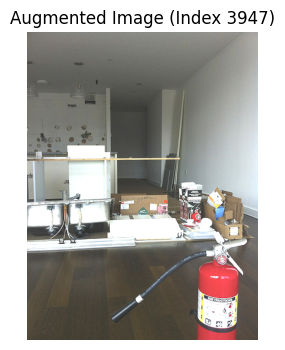

--------------------------------------------------

🔎 EXEMPLUL #2 (Index: 49944)
📝 Prompt Utilizator:
Răspunde la întrebarea următoare pe baza imaginii furnizate.

Întrebare: Ce fel de animal este? Răspuns:
🤖 Răspuns Așteptat (Ground Truth): taur


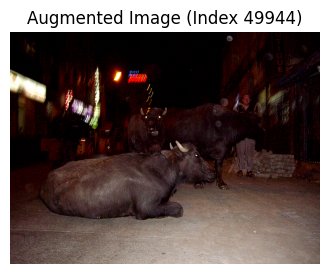

--------------------------------------------------

🔎 EXEMPLUL #3 (Index: 22335)
📝 Prompt Utilizator:
Privește cu atenție imaginea și răspunde la întrebare.

Întrebare: Care este mâncarea de deasupra mesei de sub sac? Răspuns:
🤖 Răspuns Așteptat (Ground Truth): tortilla


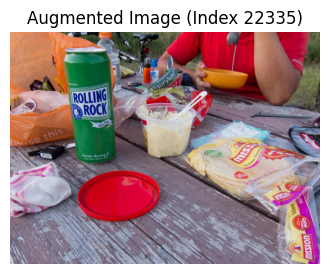

--------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt
import random

def inspect_dataset(dataset, num_samples=3):
    if not dataset:
        print("❌ Dataset-ul este gol! Ceva nu a mers bine la procesare.")
        return

    print(f"✅ Dataset size: {len(dataset)} examples")
    print("-" * 50)

    # Alegem indici aleatorii
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    for i, idx in enumerate(indices):
        entry = dataset[idx]
        messages = entry["messages"]

        # Extragem datele din formatul Unsloth/Qwen
        # Structura este: messages -> [0] User -> content -> [Image, Text]
        user_msg = messages[0]
        assistant_msg = messages[1]

        # Găsim imaginea și textul în mesajul utilizatorului
        image = None
        user_text = ""

        for content_item in user_msg["content"]:
            if content_item["type"] == "image":
                image = content_item["image"]
            elif content_item["type"] == "text":
                user_text = content_item["text"]

        answer_text = assistant_msg["content"][0]["text"]

        # Afișare
        print(f"\n🔎 EXEMPLUL #{i+1} (Index: {idx})")
        print(f"📝 Prompt Utilizator:\n{user_text}")
        print(f"🤖 Răspuns Așteptat (Ground Truth): {answer_text}")

        if image:
            plt.figure(figsize=(4, 4))
            plt.imshow(image)
            plt.axis('off')
            plt.title(f"Augmented Image (Index {idx})")
            plt.show()
        else:
            print("⚠️ Fără imagine găsită în acest exemplu.")

        print("-" * 50)

# Rulează funcția de inspecție
inspect_dataset(train_dataset, num_samples=3)

In [ ]:
if 'image_cache' in globals():
    del image_cache
    gc.collect()

In [ ]:
image_cache = None

In [ ]:
print(final_train_dataset[1])
# print(val_dataset[20])

{'messages': [{'role': 'user', 'content': [{'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=375x500 at 0x7FE37B8B62A0>}, {'type': 'text', 'text': 'Privește cu atenție imaginea și răspunde la întrebare.\n\nÎntrebare: Pe ce este peria de toaletă? Răspuns:'}]}, {'role': 'assistant', 'content': [{'type': 'text', 'text': 'hârtie igienică'}]}]}


In [ ]:
from unsloth import is_bf16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not import trl.trainer.alignprop_trainer: Failed to import trl.trainer.alignprop_trainer because of the following error (look up to see its traceback):
Failed to import trl.models.modeling_sd_base because of the following error (look up to see its traceback):
Failed to import diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion because of the following error (look up to see its traceback):
Failed to import diffusers.loaders.ip_adapter because of the following error (look up to see its traceback):
JITCallable._set_src() takes 1 positional argument but 2 were given
Unsloth: Could not import trl.trainer.ddpo_trainer: Failed to import trl.trainer.ddpo_trainer because of the following error (look up to see its traceback):
Failed to import trl.models.modeling_sd_base because of the following error (look up to see its traceback):
Fa

In [ ]:
# # Data Collator personalizat (încarcă imaginile la runtime)
# class LazyVisionDataCollator(UnslothVisionDataCollator):
#     def __call__(self, features):
#         # Înlocuiește căile cu imaginile încărcate
#         for feature in features:
#             for msg in feature["messages"]:
#                 if msg["role"] == "user":
#                     for content in msg["content"]:
#                         if content["type"] == "image" and isinstance(content["image"], str):
#                             content["image"] = Image.open(content["image"]).convert("RGB")
#         return super().__call__(features)

In [ ]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-32B-Instruct",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

==((====))==  Unsloth 2026.1.4: Fast Qwen3_Vl patching. Transformers: 4.57.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers    = True,
    finetune_language_layers  = True,
    finetune_attention_modules = True,
    finetune_mlp_modules      = True,

    # --- Recommended Changes ---
    r = 32,
    lora_alpha = 32,
    # --- End of Changes ---

    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

In [ ]:
from unsloth import is_bf16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = train_dataset,
    # eval_dataset = val_dataset, # <--- ADD THIS LINE
    args = SFTConfig(
        per_device_train_batch_size = 16,
        gradient_accumulation_steps = 8,

        # --- Recommended Changes ---
        num_train_epochs = 1,          # Use epochs for full dataset training
        # max_steps = -1,              # Ensure max_steps is not set
        learning_rate = 5e-5,          # A more stable LR for large datasets
        warmup_steps = 80,            # Warmup for 10% of the total steps
        lr_scheduler_type = "cosine",  # Cosine scheduler is often superior
        max_grad_norm = 1.0,
        # --- End of Changes ---

        fp16 = not is_bf16_supported(),
        bf16 = is_bf16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",

        # evaluation_strategy = "steps", # or "epoch"
        # eval_steps = 100,

        # Vision finetuning requirements
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        dataset_num_proc = 12,
        max_seq_length = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [ ]:
trainer_stats = trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 100,236 | Num Epochs = 1 | Total steps = 784
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 8 x 1) = 128
 "-____-"     Trainable parameters = 283,835,392 of 33,641,225,456 (0.84% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,2.772800
2,2.768700
3,2.739100
4,2.790500
5,2.763500
6,2.753100
7,2.717900
8,2.695100
9,2.664900
10,2.673800


In [ ]:
model_path = "/content/drive/My Drive/licenta/new_llm/qwen_3VL_100k_ro_augments_image_32B_verybig_v1"  # Adjust if different name


In [ ]:
model.save_pretrained(model_path)  # Local saving
tokenizer.save_pretrained(model_path)

In [ ]:
model.save_pretrained("lora_llama_vision")  # Local saving
tokenizer.save_pretrained("lora_llama_vision")